In [3]:
title = "title"
horizon_length = 16
num_envs = 24576
csv_list = [
    "/home/mil/shitanda/cpo-add/train_dir/allegro_kuka_reorientation/0725-1-0.001-1-0.05-0-0-5class_24576envs_mixed_expl_learn_param_lf_1p_26_07_02h49m59s_seed4/runs/importance_ratios.csv",
    "/home/mil/shitanda/cpo-add/train_dir/allegro_kuka_reorientation/0725-1-0.001-1-0.1-0-0-5class_24576envs_mixed_expl_learn_param_lf_1p_26_07_02h24m57s_seed4/runs/importance_ratios.csv",
    "/home/mil/shitanda/cpo-add/train_dir/allegro_kuka_reorientation/0725-1-0.001-1-0.2-0-0-5class_24576envs_mixed_expl_learn_param_lf_1p_26_07_02h49m58s_seed4/runs/importance_ratios.csv",
    "/home/mil/shitanda/cpo-add/train_dir/allegro_kuka_reorientation/0725-1-0.001-1-0.5-0-0-5class_24576envs_mixed_expl_learn_param_lf_1p_26_07_02h48m54s_seed4/runs/importance_ratios.csv",
    "/home/mil/shitanda/sapg/train_dir/allegro_kuka_reorientation/0725-SAPG-24576_24576envs_mixed_expl_learn_param_lf_1p_26_07_18h06m42s_seed4/runs/importance_ratios.csv"
    
]

title_list = [
    "KL 0.05",
    "KL 0.1",
    "KL 0.2",
    "KL 0.5",
    "SAPG",
]


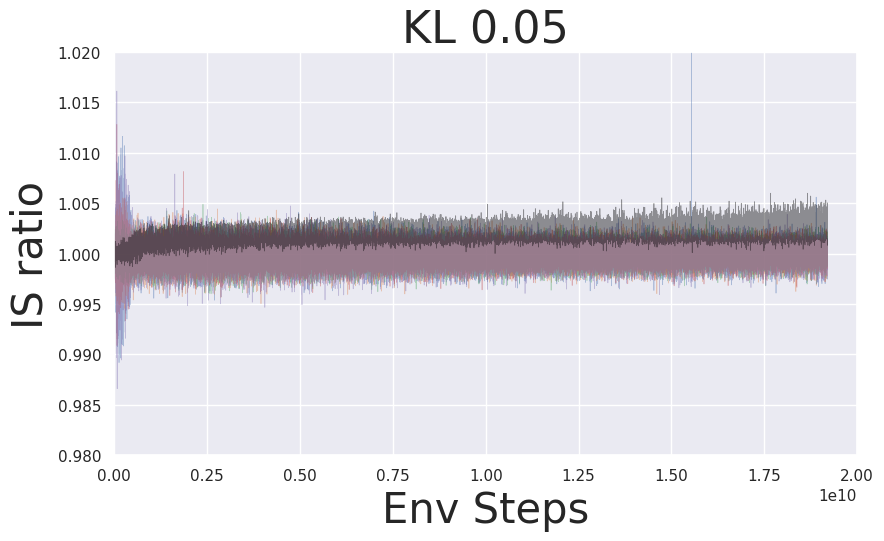

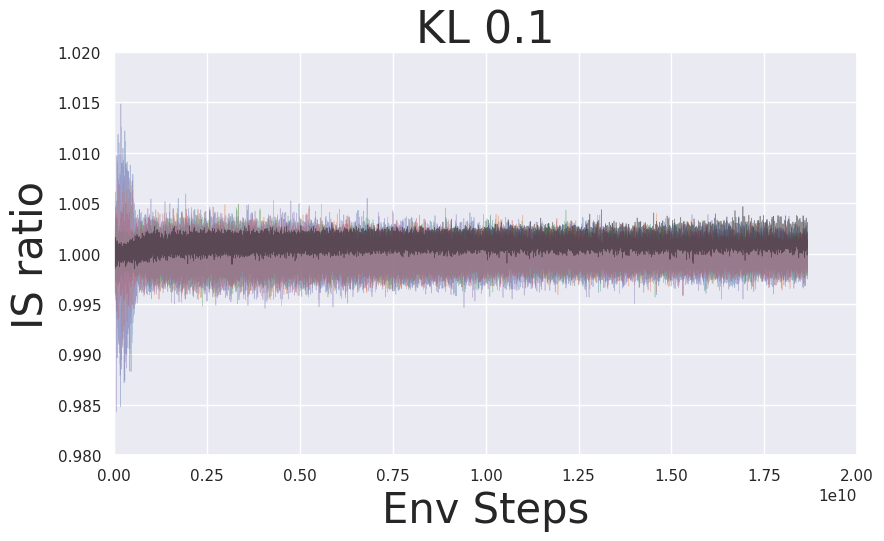

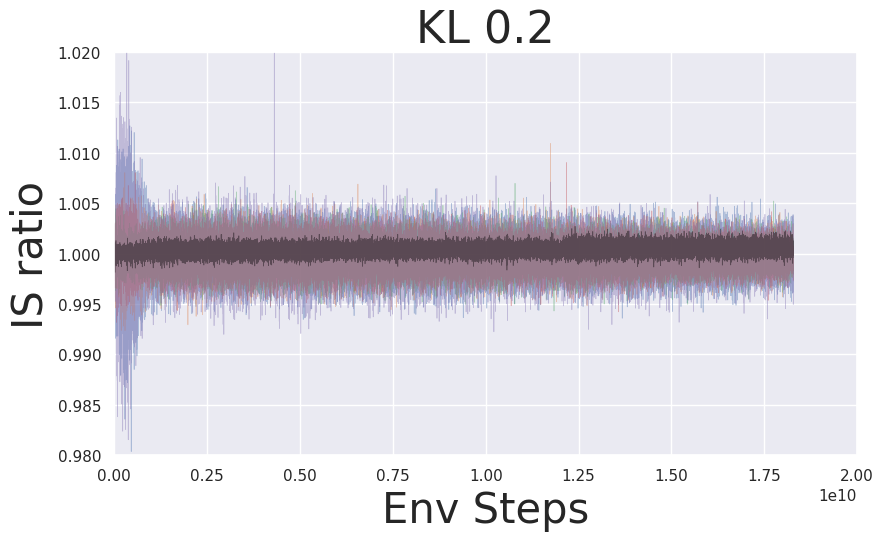

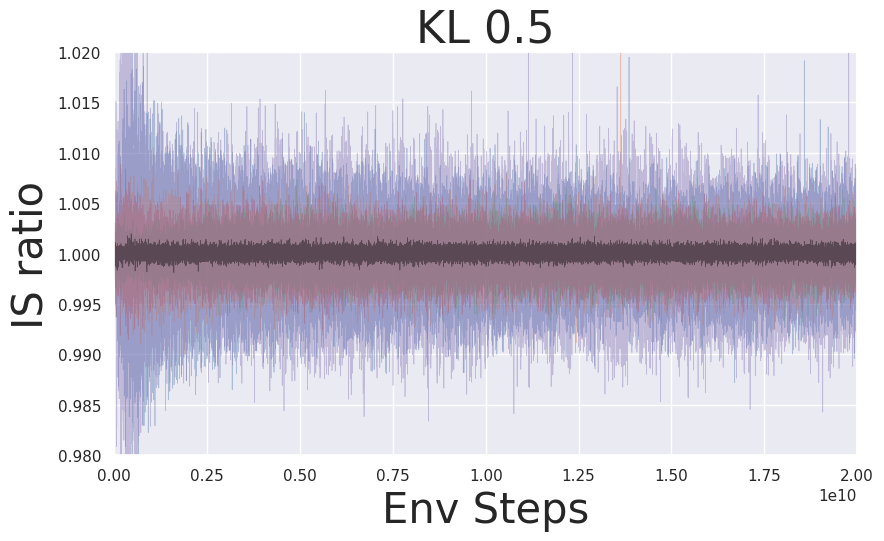

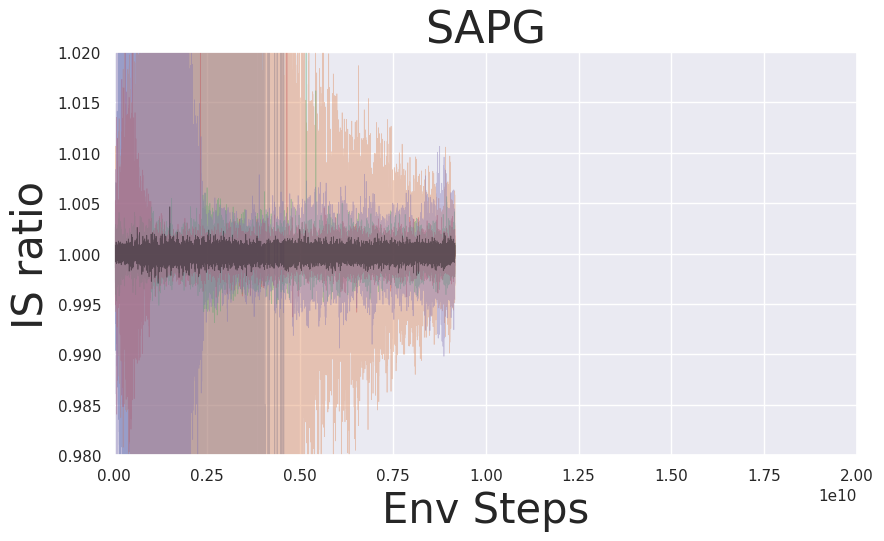

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import seaborn as sns
import numpy as np

def plot_is_ratio(csv_path, title, horizon_length, num_envs):
    sns.set()
    """
    CSVファイルからIS比率を読み込み、グラフをプロットする関数
    """
    # CSVファイルの読み込み
    csv_data = pd.read_csv(csv_path)
    
    # データをNumPy配列に変換
    data_numpy = csv_data.to_numpy()
    

    # グラフの作成
    plt.figure(figsize=(9, 6))
    
    plt.xlabel("Env Steps", fontsize=30)
    plt.ylabel("IS ratio", fontsize=30)
    plt.title(title, fontsize=32)
    plt.grid(True)
    plt.xlim(0, 2e10)
    plt.ylim(0.98, 1.02)  # Allegro Hand

    plt.tight_layout(rect=[0, 0.07, 1, 1])

    # N steps x 6のデータなので、6つの線をプロット
    for i in range(5):
        is_ratio = data_numpy[:, i]  # 1列目はEnv Stepsなので、2列目以降を使用
        x_steps = np.arange(len(is_ratio)) * horizon_length * num_envs  # 1Mステップごとにプロット
        plt.plot(x_steps, is_ratio, label=f"IS ratio {i+1}", linewidth=0.5, alpha=0.4)
    
    # 6個目(Leader自身のIS比率)は特別な色でプロット
    is_ratio_leader = data_numpy[:, 5]
    x_steps_leader = np.arange(len(is_ratio_leader)) * horizon_length * num_envs
    plt.plot(x_steps_leader, is_ratio_leader, label="IS ratio Leader", linewidth=0.5, color='black', alpha=0.4)
    
    #plt.legend(fontsize=20, loc='upper left')
    
    plt.show()

for csv_path, title in zip(csv_list, title_list):
    plot_is_ratio(csv_path, title, horizon_length, num_envs)